# Assignment 4: Examination Marks Analysis Using the Normal Distribution

Write a Python program that generates marks for 100 students using a Normal Distribution and calculates the probability associated with a user-entered marks value X.

The exam is out of 100 marks. Marks for 100 students are generated at random from a Normal Distribution, and every value is clipped so it stays within the valid 0-100 range. The Normal Distribution Probability Density Function (PDF) is written as a user-defined function built straight from the formula; no scipy.stats or other built-in distribution function is used for it. The PDF gets evaluated for every student's mark and plotted as a scatter of marks against density. A second user-defined function then takes a marks value x, checks that it falls between 0 and 100, and reports P(X = x), P(X < x), and P(X > x) in both decimal and percentage form.

Name: Ishan Kulkarni
Div: CSSE-B
Roll no.: 32

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm   # used only at the end, to double-check the manual functions

rng = np.random.default_rng(42)

In [2]:
n_students = 100
target_mean, target_std = 65, 15

raw_marks = rng.normal(target_mean, target_std, n_students)
marks = np.clip(raw_marks, 0, 100)
marks = np.round(marks).astype(int)

mean_marks = marks.mean()
std_marks = marks.std(ddof=1)

print(f"Number of students        : {n_students}")
print(f"Marks range               : {marks.min()} to {marks.max()}")
print(f"Sample mean               : {mean_marks:.2f}")
print(f"Sample standard deviation : {std_marks:.2f}")

Number of students        : 100
Marks range               : 36 to 97
Sample mean               : 64.20
Sample standard deviation : 11.62


In [3]:
def fun_normal_pdf(x, mu, sigma):
    coefficient = 1 / (sigma * math.sqrt(2 * math.pi))
    exponent = -((x - mu) ** 2) / (2 * sigma ** 2)
    return coefficient * math.exp(exponent)


densities = np.array([fun_normal_pdf(m, mean_marks, std_marks) for m in marks])

for i in range(5):
    print(f"Student {i+1:>3}: marks = {marks[i]:>3}, density = {densities[i]:.6f}")
print("...")

Student   1: marks =  70, density = 0.030304
Student   2: marks =  49, density = 0.014596
Student   3: marks =  76, density = 0.020501
Student   4: marks =  79, density = 0.015259
Student   5: marks =  36, density = 0.001809
...


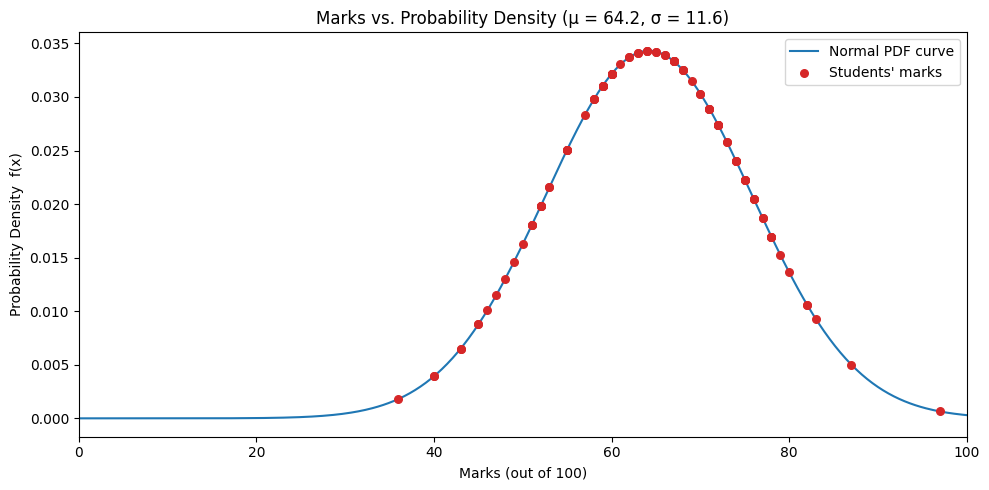

In [4]:
x_curve = np.linspace(0, 100, 500)
y_curve = [fun_normal_pdf(xc, mean_marks, std_marks) for xc in x_curve]

plt.figure(figsize=(10, 5))
plt.plot(x_curve, y_curve, color='#1f77b4', linewidth=1.5, label='Normal PDF curve')
plt.scatter(marks, densities, color='#d62728', s=30, zorder=3, label="Students' marks")
plt.title(f"Marks vs. Probability Density (μ = {mean_marks:.1f}, σ = {std_marks:.1f})")
plt.xlabel("Marks (out of 100)")
plt.ylabel("Probability Density  f(x)")
plt.xlim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
def fun_normal_cdf(x, mu, sigma):
    z = (x - mu) / (sigma * math.sqrt(2))
    return 0.5 * (1 + math.erf(z))

In [6]:
check_x = 78
manual_pdf_check = fun_normal_pdf(check_x, mean_marks, std_marks)
manual_cdf_check = fun_normal_cdf(check_x, mean_marks, std_marks)
scipy_pdf_check = norm.pdf(check_x, mean_marks, std_marks)
scipy_cdf_check = norm.cdf(check_x, mean_marks, std_marks)

check_df = pd.DataFrame({
    "Quantity": [f"f({check_x})", f"P(X < {check_x})"],
    "Manual": [manual_pdf_check, manual_cdf_check],
    "SciPy": [scipy_pdf_check, scipy_cdf_check]
})
check_df["Absolute Difference"] = (check_df["Manual"] - check_df["SciPy"]).abs()
check_df

,Quantity,Manual,SciPy,Absolute Difference
0,f(78),0.016963,0.016963,3.469447e-18
1,P(X < 78),0.882431,0.882431,0.000000e+00


In [7]:
def analyze_marks(x, mu, sigma):
    if x < 0 or x > 100:
        print(f"Invalid input: {x} is outside the valid marks range of 0-100.")
        return

    pdf_x = fun_normal_pdf(x, mu, sigma)
    p_less = fun_normal_cdf(x, mu, sigma)
    p_greater = 1 - p_less

    print(f"Results for x = {x}")
    print("-" * 40)
    print(f"P(X = {x})  [density] : {pdf_x:.6f}   ({pdf_x * 100:.4f}%)")
    print(f"P(X < {x})            : {p_less:.6f}   ({p_less * 100:.4f}%)")
    print(f"P(X > {x})            : {p_greater:.6f}   ({p_greater * 100:.4f}%)")

In [8]:
try:
    user_input = input("Enter a marks value (0-100): ")
    x_value = float(user_input)
except Exception:
    x_value = 72
    print(f"No interactive input available here — using a demo value of x = {x_value} instead.")

analyze_marks(x_value, mean_marks, std_marks)

No interactive input available here — using a demo value of x = 72 instead.


Results for x = 72
----------------------------------------
P(X = 72)  [density] : 0.027402   (2.7402%)
P(X < 72)            : 0.748903   (74.8903%)
P(X > 72)            : 0.251097   (25.1097%)
